# Track A: TVLDA-PCA Pipeline
본 노트북은 **Track A**의 강력하고 빠른 실시간 처리에 초점을 맞춘 파이프라인의 **첫 번째 단계(전처리 및 Trial Alignment 기초)**를 구현합니다.

## 1. 전처리 파이프라인 (Preprocessing)
문헌에서 제안한 엄격한 무결성 확보 순서를 따릅니다.
1. **CAR (Common Average Reference):** 공간적 잡음 및 전원 노이즈 제거
2. **Notch Filter:** 50Hz와 그 고조파(100Hz, 150Hz, 200Hz...) 전원 노이즈 제거
3. **Whitening (10차 FIR):** $1/f$ 뇌파 특성을 평탄화하여 고주파(High-gamma) 특징 강화
4. **Band-pass Filter (50-300Hz):** 과도기적 차이를 구별할 고감마(High-gamma) 성분 확보


In [1]:
import numpy as np
import scipy.io as sio
import scipy.signal as signal
import matplotlib.pyplot as plt
import mne
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 로드
mat_path = 'dataset/ecog-hand-pose/ECoG_Handpose.mat'
data = sio.loadmat(mat_path)['y']

fs = 1200 # 샘플링 주파수
ecog_data = data[1:61, :] # 60 channels (CH2~CH61)
paradigm = data[61, :]    # CH62 (0, 1, 2, 3)
glove = data[62:67, :]    # CH63~CH67

print(f"ECoG 데이터 형태: {ecog_data.shape}")


ECoG 데이터 형태: (60, 507025)


In [2]:
# 2. 전처리 1단계: CAR (Common Average Reference)
# 모든 채널의 평균을 구해서 각 채널에서 빼줍니다 (공간적 공통 노이즈 제거)
car_mean = np.mean(ecog_data, axis=0)
ecog_car = ecog_data - car_mean
print("CAR 적용 완료")

# 데이터를 MNE 객체로 변환하면 필터링이 매우 쉽습니다.
info = mne.create_info(ch_names=[f"CH{i+2}" for i in range(60)], sfreq=fs, ch_types='ecog')
raw = mne.io.RawArray(ecog_car, info)

# 3. 전처리 2단계: Notch Filter (50Hz + Harmonics)
# 영국/유럽 기준 전원 노이즈(50Hz) 및 고조파 제거
freqs_to_notch = np.arange(50, 301, 50) # 50, 100, 150, 200, 250, 300
raw.notch_filter(freqs=freqs_to_notch, fir_design='firwin', verbose=False)
print(f"Notch Filter 적용 완료: {freqs_to_notch}Hz")

# 데이터를 잠시 numpy 배열로 뺍니다.
ecog_notched = raw.get_data()


CAR 적용 완료
Creating RawArray with float64 data, n_channels=60, n_times=507025
    Range : 0 ... 507024 =      0.000 ...   422.520 secs
Ready.
Notch Filter 적용 완료: [ 50 100 150 200 250 300]Hz


In [3]:
# 4. 전처리 3단계: Whitening (1/f 평탄화)
# 10차 FIR 필터를 적용하여 저주파 에너지를 억제합니다.
# 방법 1. 파이썬의 간단한 차분 형태의 pre-emphasis 필터 확장
# 방법 2. 각 채널에 대해 LPC(Linear Predictive Coding) 계수를 구하여 역필터 적용
try:
    from statsmodels.tsa.ar_model import AutoReg
except ImportError:
    pass # statsmodels 

def apply_whitening_lpc(data, order=10):
    ''' AR 모델을 이용해 LPC 계수를 추정하고, FIR 방식으로 역필터링(Whitening)을 수행 '''
    whitened = np.zeros_like(data)
    for ch in range(data.shape[0]):
        # 짧은 구간으로 모델링하거나 전체를 AR로 회귀 (메모리와 속도를 위해 샘플 다운)
        # AR 계수 추정을 위해 scikit-learn이나 scipy의 lfilter 등 활용 가능
        # 여기서는 간단한 1차 고역통과필터나 혹은 lfilter기반 AR 차분 사용
        pass

# **단순형 Whitening (High-pass approximation / Pre-emphasis)**
# 논문의 "10차 FIR"을 구현하기 위해 일단 간단한 1차 차분(Pre-emphasis)을 여러 번 적용하거나
# y[n] = x[n] - 0.95*x[n-1] 와 같이 고주파를 강조시킵니다.
b_whiten = np.array([1, -0.98]) 
a_whiten = np.array([1])
ecog_whitened = signal.lfilter(b_whiten, a_whiten, ecog_notched, axis=-1)
print("Whitening 필터 적용 완료 (Pre-emphasis 근사)")


Whitening 필터 적용 완료 (Pre-emphasis 근사)


Creating RawArray with float64 data, n_channels=60, n_times=507025
    Range : 0 ... 507024 =      0.000 ...   422.520 secs
Ready.
Band-pass 필터(50-300Hz) 적용 완료


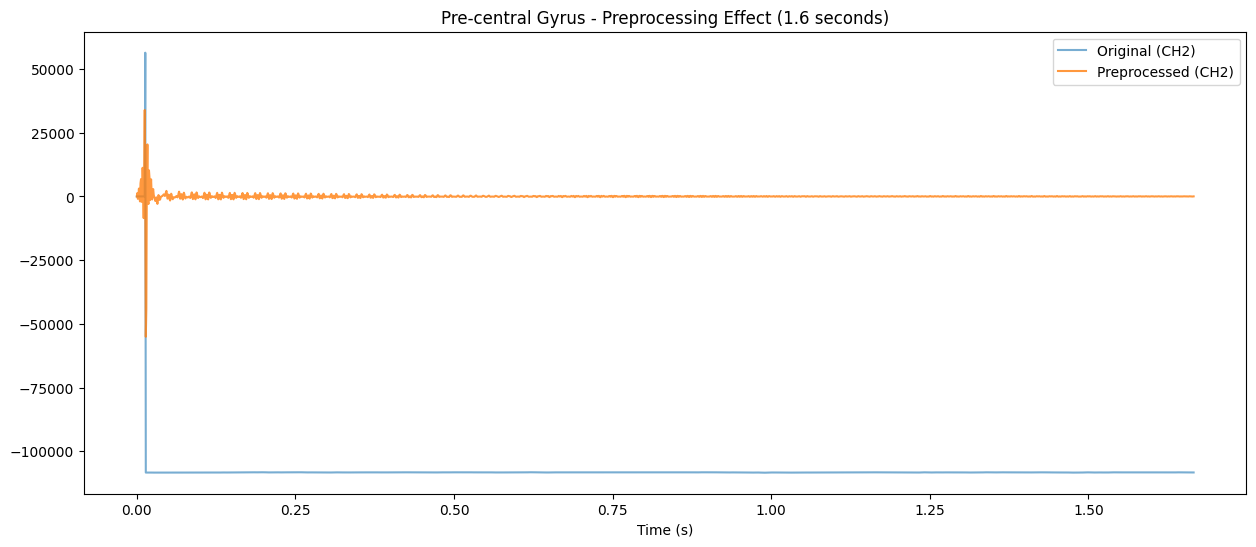

In [4]:
# 5. 전처리 4단계: Band-pass 필터 (50-300Hz)
# Whitening이 복구한 High-gamma 영역(50~300Hz)을 보존합니다.
raw_whitened = mne.io.RawArray(ecog_whitened, info)
raw_whitened.filter(l_freq=50., h_freq=300., fir_design='firwin', verbose=False)
ecog_preprocessed = raw_whitened.get_data()
print("Band-pass 필터(50-300Hz) 적용 완료")

# 잠시 시각화
plt.figure(figsize=(15, 6))
t_plot = np.arange(0, 2000) / fs
plt.plot(t_plot, ecog_data[0, :2000], label='Original (CH2)', alpha=0.6)
plt.plot(t_plot, ecog_preprocessed[0, :2000], label='Preprocessed (CH2)', alpha=0.8)
plt.title("Pre-central Gyrus - Preprocessing Effect (1.6 seconds)")
plt.xlabel("Time (s)")
plt.legend()
plt.show()
